# Spark setup

In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://downloads.apache.org/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark

tar: spark-3.5.1-bin-hadoop3.tgz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [2]:
!apt-get install -qq openjdk-17-jdk-headless
!pip install -q pyspark

In [3]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

print(os.environ["JAVA_HOME"])

/usr/lib/jvm/java-17-openjdk-amd64


# Imports

In [48]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

In [49]:
spark = SparkSession.builder \
    .appName("Midterm") \
    .master("local[*]") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.0.2


In [50]:
spark

#Load data

## Schemas

In [51]:
aisles_schema = StructType([
    StructField("aisle_id", IntegerType(), False),
    StructField("aisle", StringType(), True)
])

In [52]:
departments_schema = StructType([
    StructField("department_id", IntegerType(), False),
    StructField("department", StringType(), True)
])

In [53]:
order_products_prior_schema = StructType([
    StructField("order_id", IntegerType(), False),
    StructField("product_id", IntegerType(), False),
    StructField("add_to_cart_order", IntegerType(), True),
    StructField("reordered", IntegerType(), True)
])

In [54]:
order_products_train_schema = StructType([
    StructField("order_id", IntegerType(), False),
    StructField("product_id", IntegerType(), False),
    StructField("add_to_cart_order", IntegerType(), True),
    StructField("reordered", IntegerType(), True)
])

In [55]:
orders_schema = StructType([
    StructField("order_id", IntegerType(), False),
    StructField("user_id", IntegerType(), False),
    StructField("eval_set", StringType(), True),
    StructField("order_number", IntegerType(), True),
    StructField("order_dow", IntegerType(), True),
    StructField("order_hour_of_day", IntegerType(), True),
    StructField("days_since_prior_order", DoubleType(), True)
])

In [56]:
products_schema = StructType([
    StructField("product_id", IntegerType(), False),
    StructField("product_name", StringType(), True),
    StructField("aisle_id", IntegerType(), False),
    StructField("department_id", IntegerType(), False)
])

## Read data

In [57]:
aisles = spark.read.csv(
    "/content/aisles.csv",
    header=True,
    schema=aisles_schema
)

aisles.printSchema()
aisles.show(5)

root
 |-- aisle_id: integer (nullable = true)
 |-- aisle: string (nullable = true)

+--------+--------------------+
|aisle_id|               aisle|
+--------+--------------------+
|       1|prepared soups sa...|
|       2|   specialty cheeses|
|       3| energy granola bars|
|       4|       instant foods|
|       5|marinades meat pr...|
+--------+--------------------+
only showing top 5 rows


In [58]:
departments = spark.read.csv(
    "/content/departments.csv",
    header=True,
    schema=departments_schema
)

departments.printSchema()
departments.show(5)

root
 |-- department_id: integer (nullable = true)
 |-- department: string (nullable = true)

+-------------+----------+
|department_id|department|
+-------------+----------+
|            1|    frozen|
|            2|     other|
|            3|    bakery|
|            4|   produce|
|            5|   alcohol|
+-------------+----------+
only showing top 5 rows


In [59]:
order_products_prior = spark.read.csv(
    "/content/order_products__prior.csv",
    header=True,
    schema=order_products_prior_schema
)

order_products_prior.printSchema()
order_products_prior.show(5)

root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)

+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|       2|     33120|                1|        1|
|       2|     28985|                2|        1|
|       2|      9327|                3|        0|
|       2|     45918|                4|        1|
|       2|     30035|                5|        0|
+--------+----------+-----------------+---------+
only showing top 5 rows


In [60]:
order_products_train = spark.read.csv(
    "/content/order_products__train.csv",
    header=True,
    schema=order_products_train_schema
)

order_products_train.printSchema()
order_products_train.show(5)

root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)

+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|       1|     49302|                1|        1|
|       1|     11109|                2|        1|
|       1|     10246|                3|        0|
|       1|     49683|                4|        0|
|       1|     43633|                5|        1|
+--------+----------+-----------------+---------+
only showing top 5 rows


In [61]:
orders = spark.read.csv(
    "/content/orders.csv",
    header=True,
    schema=orders_schema
)

orders.printSchema()
orders.show(5)

root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)

+--------+-------+--------+------------+---------+-----------------+----------------------+
|order_id|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|
+--------+-------+--------+------------+---------+-----------------+----------------------+
| 2539329|      1|   prior|           1|        2|                8|                  NULL|
| 2398795|      1|   prior|           2|        3|                7|                  15.0|
|  473747|      1|   prior|           3|        3|               12|                  21.0|
| 2254736|      1|   prior|           4|        4|                7|                  29.0|
|  431534|      1|   prior|           

In [62]:
products = spark.read.csv(
    "/content/products.csv",
    header=True,
    schema=products_schema
)

products.printSchema()
products.show(5)

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: integer (nullable = true)
 |-- department_id: integer (nullable = true)

+----------+--------------------+--------+-------------+
|product_id|        product_name|aisle_id|department_id|
+----------+--------------------+--------+-------------+
|         1|Chocolate Sandwic...|      61|           19|
|         2|    All-Seasons Salt|     104|           13|
|         3|Robust Golden Uns...|      94|            7|
|         4|Smart Ones Classi...|      38|            1|
|         5|Green Chile Anyti...|       5|           13|
+----------+--------------------+--------+-------------+
only showing top 5 rows


**Տվյալների կառուցվածք և սխեմաների սահմանում**

Տվյալների հավաքածուն բաղկացած է վեց փոխկապակցված աղյուսակներից, որոնք միասին ձևավորում են ռելացիոն տվյալների բազայի կառուցվածք։ Այս կառուցվածքը հնարավորություն է տալիս իրականացնել բազմաչափ վերլուծություն և կիրառել մեծ տվյալների մշակման մեթոդներ։

**Աղյուսակների տեսակները**

Տվյալների բազայում կարելի է առանձնացնել երկու հիմնական տիպի աղյուսակներ՝

- **Չափողական (dimension) աղյուսակներ**
  - `aisles`
  - `departments`

  Այս աղյուսակները պարունակում են նկարագրական տվյալներ և օգտագործվում են որպես հղումներ (reference data)։

- **Գործառնական (fact) աղյուսակներ**
  - `order_products_prior`
  - `order_products_train`

  Այս աղյուսակները ներկայացնում են գործարքային տվյալներ և արտացոլում են պատվերների և ապրանքների միջև կապը։

- **Կենտրոնական աղյուսակ**
  - `orders`

  Պարունակում է պատվերների մասին տեղեկատվություն՝ օգտատիրոջ, ժամանակի և պատվերի հերթականության վերաբերյալ։

- **Կապող աղյուսակ**
  - `products`

  Միացնում է գործարքային տվյալները չափողական աղյուսակների հետ՝ ապահովելով բազմամակարդակ վերլուծության հնարավորություն։

---

**Սխեմաների սահմանման անհրաժեշտությունը**

Չնայած Spark-ը կարող է ավտոմատ կերպով որոշել տվյալների տիպերը (`inferSchema=True`), այս նախագծում սխեմաները սահմանվել են ձեռքով՝ հետևյալ պատճառներով․

- ապահովելու տվյալների տիպերի ճշգրտությունը,
- բարձրացնելու մշակման արագությունը,
- կանխելու սխալ տիպերի առաջացումը (օրինակ՝ թվային արժեքների ընթերցում որպես string),
- ապահովելու համատեղելիություն հետագա վերլուծության և մոդելավորման փուլերում։

---

**Տվյալների տիպերի կարևոր նկատառումներ**

Հատուկ ուշադրություն է դարձվել որոշ դաշտերի տիպերին․

- `order_id`, `product_id`, `user_id` դաշտերը սահմանվել են որպես ամբողջ թվեր (integer), քանի որ դրանք հանդես են գալիս որպես նույնացուցիչներ (identifiers),
- `aisle_id` և `department_id` դաշտերը սկզբնական ընթերցման ժամանակ սխալմամբ ճանաչվել էին որպես string, սակայն ուղղվել են integer տիպի՝ ապահովելու համար ճիշտ join-երի իրականացումը,
- `days_since_prior_order` դաշտը սահմանվել է որպես float (double), քանի որ պարունակում է տասնորդական արժեքներ և բացակա տվյալներ (NULL)։

---

**Տվյալների կառուցվածքի նշանակությունը**

Տվյալների նման կառուցվածքը թույլ է տալիս․

- իրականացնել բազմաաղյուսակային միացումներ (joins),
- ուսումնասիրել օգտատերերի վարքագիծը,
- վերլուծել պատվերների և ապրանքների միջև կապերը,
- կառուցել մեքենայական ուսուցման մոդելներ՝ օրինակ՝ ապրանքի վերապատվիրման հավանականությունը կանխատեսելու համար։

Այսպիսով, տվյալների բազայի ճիշտ կառուցումը և սխեմաների հստակ սահմանումը հանդիսանում են հետագա վերլուծության և մոդելավորման հիմնաքարը։

# 1.Data Quality Analysis

## Missing Values Analysis

In [63]:
def missing_values(df, name):
    print(f"\n===== Missing Values in {name} =====")
    df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]).show()

missing_values(orders, "orders")
missing_values(order_products_prior, "order_products_prior")
missing_values(order_products_train, "order_products_train")
missing_values(products, "products")
missing_values(aisles, "aisles")
missing_values(departments, "departments")


===== Missing Values in orders =====
+--------+-------+--------+------------+---------+-----------------+----------------------+
|order_id|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|
+--------+-------+--------+------------+---------+-----------------+----------------------+
|       0|      0|       0|           0|        0|                0|                206209|
+--------+-------+--------+------------+---------+-----------------+----------------------+


===== Missing Values in order_products_prior =====
+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|       0|         0|                0|        0|
+--------+----------+-----------------+---------+


===== Missing Values in order_products_train =====
+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+-------

Տվյալների վերլուծության արդյունքում պարզվեց, որ բացակա արժեքներ հիմնականում չկան։  
Բացակա արժեքներ առկա են միայն `orders` աղյուսակի `days_since_prior_order` սյունակում (206,209 գրառում), ինչը բացատրվում է նրանով, որ դրանք օգտատերերի առաջին պատվերներն են և բնական (expected) են։

Միևնույն ժամանակ, `products` աղյուսակում հայտնաբերվել են մի քանի բացակա արժեքներ (`aisle_id`, `department_id`), որոնք հանդիսանում են արտաքին բանալիներ։ Սա արդեն տվյալների որակի խնդիր է։

**Ազդեցություն (Impact)**

- Բացակա արժեքները `orders` աղյուսակում կարող են ազդել ժամանակային վերլուծության վրա, եթե սխալ մշակվեն։
- `products` աղյուսակի բացակա արժեքները կարող են բերել տվյալների կորստի JOIN-երի ժամանակ և թերի վերլուծության։

**Լուծումներ (Fix)**

- `days_since_prior_order` - պահել որպես NULL կամ փոխարինել 0-ով (նշելով առաջին պատվերը)  
- `products` - հեռացնել բացակա գրառումները

**Եզրակացություն**

Ընդհանուր առմամբ տվյալների որակը բարձր է, սակայն առկա են փոքր խնդիրներ, որոնք պետք է հաշվի առնել՝ ճշգրիտ վերլուծություն ապահովելու համար։

## Data Type Issues

**Տվյալների տիպերի խնդիրներ**

Տվյալների նախնական բեռնման ընթացքում, երբ օգտագործվում էր ավտոմատ սխեմայի որոշում (inferSchema), հայտնաբերվեց, որ որոշ դաշտեր սխալմամբ ճանաչվել են որպես տեքստային (string) տիպ։ Մասնավորապես, `products` աղյուսակի `aisle_id` և `department_id` դաշտերը պետք է լինեն ամբողջ թվեր (integer), քանի որ հանդիսանում են արտաքին բանալիներ։

**Ազդեցություն**

Տվյալների սխալ տիպերը կարող են խոչընդոտել աղյուսակների ճիշտ միացմանը (JOIN), բերել տվյալների կորստի կամ սխալ վերլուծության արդյունքների։ Սա հատկապես կարևոր է, քանի որ տվյալների բազան ունի ռելացիոն կառուցվածք և հիմնված է տարբեր աղյուսակների միջև կապերի վրա։

**Լուծում**

Այս խնդիրը լուծելու համար տվյալների բեռնման ընթացքում սահմանվեցին հստակ սխեմաներ բոլոր աղյուսակների համար։ Դրա արդյունքում բոլոր նույնացուցիչ դաշտերը (`order_id`, `product_id`, `aisle_id`, `department_id` և այլն) սահմանվեցին որպես ամբողջ թվեր (integer), ինչը ապահովում է տվյալների համադրելիությունը և ճիշտ JOIN-երի իրականացումը։

**Եզրակացություն**

Այսպիսով, տվյալների տիպերի խնդիրները հայտնաբերվեցին և ուղղվեցին սխեմաների հստակ սահմանման միջոցով, ինչը ապահովում է հետագա վերլուծության և մոդելավորման հուսալիությունը։

## Referential Integrity Check

In [64]:
order_products = order_products_prior.unionByName(order_products_train).dropDuplicates()

In [65]:
# order_products → orders
missing_orders = order_products.select("order_id") \
    .subtract(orders.select("order_id"))

print("Missing order references:", missing_orders.count())


# order_products → products
missing_products = order_products.select("product_id") \
    .subtract(products.select("product_id"))

print("Missing product references:", missing_products.count())


# products → aisles
missing_aisles = products.select("aisle_id") \
    .subtract(aisles.select("aisle_id"))

print("Missing aisle references:", missing_aisles.count())


# products → departments
missing_departments = products.select("department_id") \
    .subtract(departments.select("department_id"))

print("Missing department references:", missing_departments.count())

Missing order references: 0
Missing product references: 0
Missing aisle references: 1
Missing department references: 1


**Ռելացիոն ամբողջականության ստուգում (Referential Integrity)**

Տվյալների բազայի աղյուսակների միջև կապերի ճշգրտությունը ստուգելու համար իրականացվեց արտաքին բանալիների (foreign keys) վերլուծություն։

Արդյունքները ցույց տվեցին՝

- `order_id` → ամբողջությամբ համընկնում է `orders` աղյուսակի հետ (0 բացակայող արժեք)
- `product_id` → ամբողջությամբ համընկնում է `products` աղյուսակի հետ (0 բացակայող արժեք)
- `aisle_id` → կա 1 բացակայող հղում
- `department_id` → կա 1 բացակայող հղում

**Ազդեցություն**  
`aisle_id` և `department_id` դաշտերի բացակայող հղումները նշանակում են, որ որոշ ապրանքներ չեն կապվում համապատասխան կատեգորիաների հետ։  
Սա կարող է հանգեցնել տվյալների կորստի JOIN-երի ժամանակ և թերի վերլուծության (օրինակ՝ ըստ բաժինների կամ aisle-ների խմբավորումներում)։

**Լուծում**  
Քանի որ բացակայող արժեքների քանակը շատ փոքր է (միայն 1 գրառում յուրաքանչյուր դեպքում), առավել նպատակահարմար է՝

- հեռացնել այդ գրառումները,  

**Եզրակացություն**  
Ընդհանուր առմամբ տվյալների բազան պահպանում է բարձր ռելացիոն ամբողջականություն, սակայն առկա են փոքր խախտումներ, որոնք անհրաժեշտ է հաշվի առնել հետագա վերլուծության ընթացքում։

# 2.Data Manipulation, Joins, and UDF

## Data Preparation and Integration

In [66]:
products_clean = products.filter(
    col("aisle_id").isNotNull() & col("department_id").isNotNull()
)

print("Original products:", products.count())
print("Cleaned products:", products_clean.count())
print("Removed products:", products.count() - products_clean.count())

Original products: 49688
Cleaned products: 49687
Removed products: 1


In [67]:
order_products = order_products_prior.union(order_products_train)

cleaned_df = order_products \
    .join(orders, on="order_id", how="inner") \
    .join(products_clean, on="product_id", how="inner") \
    .join(aisles, on="aisle_id", how="inner") \
    .join(departments, on="department_id", how="inner")

cleaned_df.show(5)
print("Rows:", cleaned_df.count())

+-------------+--------+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+--------------------+----------------+----------+
|department_id|aisle_id|product_id|order_id|add_to_cart_order|reordered|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|        product_name|           aisle|department|
+-------------+--------+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+--------------------+----------------+----------+
|           16|      53|     30597|      12|                1|        1| 152610|   prior|          22|        6|                8|                  10.0|French Vanilla Co...|           cream|dairy eggs|
|           16|      84|     15221|      12|                2|        1| 152610|   prior|          22|        6|                8|                  10.0|             2% Milk|            mi

Տվյալների որակի ստուգումից հետո հեռացվեց մեկ գրառում `products` աղյուսակից, քանի որ այն չուներ վավեր `aisle_id` և `department_id` արժեքներ։ Քանի որ այս դաշտերը անհրաժեշտ են աղյուսակների ճիշտ միացման համար, նման գրառումների պահպանումը կարող էր բերել թերի կամ սխալ կատեգորիական վերլուծության։

Մաքրված տվյալների հավաքածուն ստեղծվեց՝ միացնելով պատվերների (orders), ապրանքների (products), ինչպես նաև aisle և department աղյուսակները order-product տվյալների հետ։ Ստացված վերջնական dataset-ը պարունակում է 33,819,103 գրառում և ներառում է ինչպես գործարքային, այնպես էլ կատեգորիական տվյալներ։

Միացումները իրականացվել են հիմնական բանալիների միջոցով (`order_id`, `product_id`, `aisle_id`, `department_id`), ինչը ապահովում է տվյալների ճիշտ համադրումը և ամբողջականությունը։

## Duplicate Handling and Validation

In [68]:
duplicate_check = order_products.groupBy("order_id", "product_id") \
    .count() \
    .filter(col("count") > 1)

print("Duplicate order-product pairs:", duplicate_check.count())

Duplicate order-product pairs: 0


**Duplicate Detection in Joined Dataset**

Duplicate-ների ստուգումը իրականացվեց `(order_id, product_id)` զույգերի մակարդակով, քանի որ բիզնես տրամաբանությամբ մեկ պատվերի մեջ նույն ապրանքը պետք է հայտնվի մեկ անգամ։

Ստուգման արդյունքում կրկնվող `(order_id, product_id)` զույգեր չհայտնաբերվեցին (`0 duplicate pairs`)։ Սա նշանակում է, որ տվյալների միավորման և մաքրման արդյունքում յուրաքանչյուր order-product կապ ներկայացված է մեկ անգամ։

**Ազդեցություն**  
Եթե այսպիսի duplicate-ներ լինեին, դրանք կխեղաթյուրեին ապրանքների հաճախականության հաշվարկները, օգտատերերի մակարդակով aggregations-ը և հետագա ML վերլուծությունը։

**Լուծում**  
Duplicate-ները ստուգվեցին ոչ թե կուրորեն ամբողջ տողի մակարդակով, այլ ըստ բիզնես բանալիի՝ `(order_id, product_id)`։ Սա logic-based մոտեցում է և ապահովում է, որ իրական կրկնությունները չազդեն վերլուծության վրա։

**Եզրակացություն**  
Join-երը duplication artifact չեն ստեղծել, քանի որ բոլոր միացումները կատարվել են համապատասխան բանալիներով, և վերջնական տվյալներում կրկնվող order-product զույգեր չկան։

## Product Name Normalization

In [69]:
cleaned_df = cleaned_df.withColumn(
    "product_name_normalized",
    trim(
        regexp_replace(
            lower(col("product_name")),
            "[^a-zA-Z0-9 ]",
            ""
        )
    )
)

cleaned_df.select("product_name", "product_name_normalized").show(5, False)

+----------------------------------+----------------------------------+
|product_name                      |product_name_normalized           |
+----------------------------------+----------------------------------+
|French Vanilla Coffee Creamer     |french vanilla coffee creamer     |
|2% Milk                           |2 milk                            |
|Cherubs Heavenly Salad Tomatoes   |cherubs heavenly salad tomatoes   |
|Extra Creamy Dairy Whipped Topping|extra creamy dairy whipped topping|
|100% Cranberry Juice              |100 cranberry juice               |
+----------------------------------+----------------------------------+
only showing top 5 rows


**Product Name Normalization**

Ապրանքների անունների նորմալացման արդյունքում ստացվեց միատեսակ և ստանդարտացված ձևաչափ։ Օրինակ՝  
- "French Vanilla Coffee Creamer" → "french vanilla coffee creamer"  
- "2% Milk" → "2 milk"

**Ազդեցություն**  
Տարբեր գրառումների դեպքում նույն ապրանքը կարող է ունենալ տարբեր ձևաչափեր (մեծատառ, հատուկ նշաններ և այլն), ինչը կարող է խանգարել ճիշտ խմբավորմանը և հաճախականության հաշվարկներին։

**Լուծում**  
Օգտագործվեցին built-in ֆունկցիաներ (`lower`, `regexp_replace`, `trim`), որպեսզի տեքստը բերվի միատեսակ տեսքի՝ հեռացնելով մեծատառերի տարբերությունը և հատուկ նշանները։

**Եզրակացություն**  
Նորմալացման արդյունքում ապահովվում է, որ նույն ապրանքները ներկայացվեն նույն ձևով, ինչը կարևոր է ճշգրիտ վերլուծության և հետագա հաշվարկների համար։

##Total spend per user

In [70]:
user_spend = cleaned_df.groupBy("user_id") \
    .count() \
    .withColumnRenamed("count", "total_purchases")

user_spend.orderBy(col("total_purchases").desc()).show(10)

+-------+---------------+
|user_id|total_purchases|
+-------+---------------+
| 201268|           3725|
| 129928|           3689|
| 164055|           3089|
| 176478|           2952|
| 186704|           2936|
| 137629|           2931|
| 182401|           2929|
|  33731|           2912|
| 108187|           2760|
|   4694|           2735|
+-------+---------------+
only showing top 10 rows


Total Purchases per User

Քանի որ տվյալների հավաքածուն չի պարունակում ապրանքների գների մասին տեղեկատվություն, ընդհանուր ծախսը (total spend) գնահատվեց որպես գնված ապրանքների ընդհանուր քանակ (total purchases) յուրաքանչյուր օգտատիրոջ համար։

Արդյունքները ցույց են տալիս, որ որոշ օգտատերեր ունեն զգալիորեն ավելի բարձր ակտիվություն։ Օրինակ՝ օգտատեր 201268-ը կատարել է 3725 գնում, ինչը զգալիորեն գերազանցում է մյուսներին։

**Ազդեցություն**  
Այս չափանիշը թույլ է տալիս գնահատել օգտատերերի ակտիվությունը և տարբերակել բարձր և ցածր ակտիվությամբ օգտատերերին։ Այն կարող է օգտագործվել segmentation-ի, personalization-ի և ML մոդելների կառուցման համար։

**Լուծում**  
Քանի որ price սյունակ չկա, total spend-ը փոխարինվեց գնումների քանակով, ինչը տրամաբանական մոտեցում է նման տվյալների դեպքում։

**Եզրակացություն**  
Օգտատերերի ակտիվության մակարդակը զգալիորեն տարբերվում է, ինչը կարևոր insight է հետագա վերլուծության և մոդելավորման համար։

## Top 3 Products per User (by frequency)

In [71]:
user_product_counts = cleaned_df.groupBy("user_id", "product_name_normalized") \
    .count() \
    .withColumnRenamed("count", "frequency")

In [72]:
window_spec = Window.partitionBy("user_id").orderBy(col("frequency").desc())

top_products = user_product_counts.withColumn(
    "rank",
    row_number().over(window_spec)
)

In [73]:
top_3_products = top_products.filter(col("rank") <= 3)

top_3_products.show(10)

+-------+-----------------------+---------+----+
|user_id|product_name_normalized|frequency|rank|
+-------+-----------------------+---------+----+
|      1|                   soda|       11|   1|
|      1|    original beef jerky|       10|   2|
|      1|             pistachios|       10|   3|
|      3|   vanilla unsweeten...|       10|   1|
|      3|        organic avocado|        9|   2|
|      3|   organic baby spinach|        8|   3|
|      5|        red raspberries|        4|   1|
|      5|   organic blackberries|        4|   2|
|      5|   plain whole milk ...|        3|   3|
|      6|   ground turkey breast|        2|   1|
+-------+-----------------------+---------+----+
only showing top 10 rows


Յուրաքանչյուր օգտատիրոջ համար հաշվարկվեց ամենաշատ գնված ապրանքների հաճախականությունը և ընտրվեցին լավագույն 3-ը՝ օգտագործելով window functions և ranking։

Արդյունքները ցույց են տալիս, որ օգտատերերը ունեն հստակ նախընտրություններ։ Օրինակ՝  
- User 1-ը հաճախ գնում է "soda", "original beef jerky" և "pistachios"
- User 3-ը նախընտրում է "vanilla unsweetened","organic avocado" և "organic baby spinach"

**Ազդեցություն**  
Այս վերլուծությունը թույլ է տալիս հասկանալ օգտատերերի գնման վարքագիծը և բացահայտել նրանց նախընտրած ապրանքները։ Սա կարևոր է personalization-ի, recommendation համակարգերի և մարքեթինգային ռազմավարությունների համար։

**Լուծում**  
Օգտագործվեց `(user_id, product_name_normalized)` մակարդակով հաճախականության հաշվարկ և `row_number()` window function՝ յուրաքանչյուր օգտատիրոջ համար լավագույն ապրանքները դասակարգելու համար։

**Եզրակացություն**  
Օգտատերերի վարքագիծը ցույց է տալիս կրկնվող գնումների հստակ pattern-ներ, ինչը հնարավորություն է տալիս կառուցել արդյունավետ recommendation համակարգեր։

# 3.Spark Job Analysis and Optimization

## Explain Analysis

In [74]:
cleaned_df.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (29)
+- Project (28)
   +- BroadcastHashJoin Inner BuildRight (27)
      :- Project (23)
      :  +- BroadcastHashJoin Inner BuildRight (22)
      :     :- Project (18)
      :     :  +- BroadcastHashJoin Inner BuildRight (17)
      :     :     :- Project (13)
      :     :     :  +- SortMergeJoin Inner (12)
      :     :     :     :- Sort (7)
      :     :     :     :  +- Exchange (6)
      :     :     :     :     +- Union (5)
      :     :     :     :        :- Filter (2)
      :     :     :     :        :  +- Scan csv  (1)
      :     :     :     :        +- Filter (4)
      :     :     :     :           +- Scan csv  (3)
      :     :     :     +- Sort (11)
      :     :     :        +- Exchange (10)
      :     :     :           +- Filter (9)
      :     :     :              +- Scan csv  (8)
      :     :     +- BroadcastExchange (16)
      :     :        +- Filter (15)
      :     :           +- Scan csv  (14)
      :     +- BroadcastExchange 

`.explain()` մեթոդով ստուգվեց Spark-ի ֆիզիկական execution plan-ը։ Արդյունքները ցույց են տալիս, որ հիմնական ծանր գործողությունը մեծ աղյուսակների միացումն է՝ `order_products` և `orders` աղյուսակների միջև։

Execution plan-ում երևում են հետևյալ կարևոր գործողությունները․

**Հայտնաբերված bottleneck-ներ**  
- `Exchange hashpartitioning(order_id, 200)` → առաջացնում է shuffle, քանի որ տվյալները վերաբաշխվում են ըստ `order_id`
- `Sort` → անհրաժեշտ է `SortMergeJoin` կատարելու համար
- `SortMergeJoin` → համեմատաբար ծանր join է, քանի որ միացվում են երկու մեծ աղյուսակներ
- Փոքր աղյուսակների (`products`, `aisles`, `departments`) համար օգտագործվում է `BroadcastHashJoin`, ինչը լավ է, քանի որ նվազեցնում է shuffle-ը

**Եզրակացություն**  
Հիմնական performance bottleneck-ը առաջանում է մեծ աղյուսակների join-ի ժամանակ։ Մնացած join-երը համեմատաբար օպտիմալ են, քանի որ Spark-ը փոքր աղյուսակները broadcast է անում։

## Optimization Code

In [75]:
spark.conf.set("spark.sql.shuffle.partitions", "64")

order_products_optimized = order_products.repartition("order_id")
orders_optimized = orders.repartition("order_id")

cleaned_df_optimized = order_products_optimized \
    .join(orders_optimized, on="order_id", how="inner") \
    .join(broadcast(products_clean), on="product_id", how="inner") \
    .join(broadcast(aisles), on="aisle_id", how="inner") \
    .join(broadcast(departments), on="department_id", how="inner") \
    .withColumn(
        "product_name_normalized",
        trim(
            regexp_replace(
                lower(col("product_name")),
                "[^a-zA-Z0-9 ]",
                ""
            )
        )
    )

cleaned_df_optimized.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (29)
+- Project (28)
   +- BroadcastHashJoin Inner BuildRight (27)
      :- Project (23)
      :  +- BroadcastHashJoin Inner BuildRight (22)
      :     :- Project (18)
      :     :  +- BroadcastHashJoin Inner BuildRight (17)
      :     :     :- Project (13)
      :     :     :  +- SortMergeJoin Inner (12)
      :     :     :     :- Sort (7)
      :     :     :     :  +- Exchange (6)
      :     :     :     :     +- Union (5)
      :     :     :     :        :- Filter (2)
      :     :     :     :        :  +- Scan csv  (1)
      :     :     :     :        +- Filter (4)
      :     :     :     :           +- Scan csv  (3)
      :     :     :     +- Sort (11)
      :     :     :        +- Exchange (10)
      :     :     :           +- Filter (9)
      :     :     :              +- Scan csv  (8)
      :     :     +- BroadcastExchange (16)
      :     :        +- Filter (15)
      :     :           +- Scan csv  (14)
      :     +- BroadcastExchange 

Optimization-ի փուլում հիմնական ուշադրությունը դարձվեց shuffle operations-ի նվազեցմանը և join-երի արդյունավետության բարձրացմանը։

Կատարված փոփոխությունները՝

**1. Shuffle partitions-ի նվազեցում**  
Սկզբնական execution plan-ում Spark-ը օգտագործում էր `hashpartitioning(order_id, 200)`։ Քանի որ աշխատանքը կատարվում է Colab միջավայրում և տվյալների չափը սահմանափակ է, 200 partition-ը կարող էր ստեղծել ավելորդ scheduling overhead։ Այդ պատճառով `spark.sql.shuffle.partitions` արժեքը իջեցվեց 64-ի։

**2. Repartition ըստ join key-ի**  
`order_products` և `orders` աղյուսակները նախապես repartition արվեցին ըստ `order_id` դաշտի։ Սա օգնում է, որ մեծ աղյուսակների join-ը կատարվի ավելի կազմակերպված partitioning-ով։

**3. Broadcast join փոքր աղյուսակների համար**  
Փոքր dimension աղյուսակները (`products`, `aisles`, `departments`) միացվեցին `broadcast()`-ի միջոցով։ Սա նվազեցնում է shuffle-ի անհրաժեշտությունը, քանի որ փոքր աղյուսակները ուղարկվում են worker-ներին և join-ը կատարվում է տեղային մակարդակում։

**4. Built-in functions instead of UDF**  
Ապրանքների անունների նորմալացման համար օգտագործվեցին Spark-ի built-in ֆունկցիաներ (`lower`, `regexp_replace`, `trim`)՝ Python UDF-ի փոխարեն։ Built-in functions-ը օպտիմալացվում են Spark Catalyst optimizer-ի կողմից և սովորաբար ավելի արագ են աշխատում։

**Եզրակացություն**  
Optimization-ից հետո execution plan-ում shuffle partition-ների քանակը նվազեց 200-ից 64-ի, իսկ փոքր աղյուսակների join-երը շարունակեցին իրականացվել `BroadcastHashJoin`-ով։ Սա նվազեցնում է ավելորդ shuffle և scheduling overhead-ը, ինչի արդյունքում pipeline-ը դառնում է ավելի արդյունավետ։

**Կատարողականի բարելավման հիմնավորում (Performance Improvement Justification)**  

Օպտիմալացումից հետո shuffle partition-ների քանակը նվազեցվեց, ինչպես նաև մեծ աղյուսակների join-երը կատարվեցին ավելի արդյունավետ՝ repartition-ի միջոցով։ Սա նվազեցնում է տվյալների տեղափոխումը տարբեր հանգույցների միջև և իջեցնում հաշվարկային բեռնվածությունը։

Բացի այդ, փոքր աղյուսակների համար կիրառված broadcast join-ը թույլ է տալիս խուսափել ավելորդ shuffle գործողություններից, իսկ built-in ֆունկցիաների օգտագործումը UDF-ի փոխարեն հնարավորություն է տալիս Spark-ին կիրառել ներքին օպտիմալացումներ։

Ընդհանուր առմամբ, այս փոփոխությունները նպաստում են pipeline-ի ավելի արագ և արդյունավետ կատարմանը՝ նվազեցնելով ավելորդ տվյալների վերադասավորումը և բարելավելով join-երի կատարողականը։

# 4.Analytics Report and Visualization

## Top Products (Visualization 1)

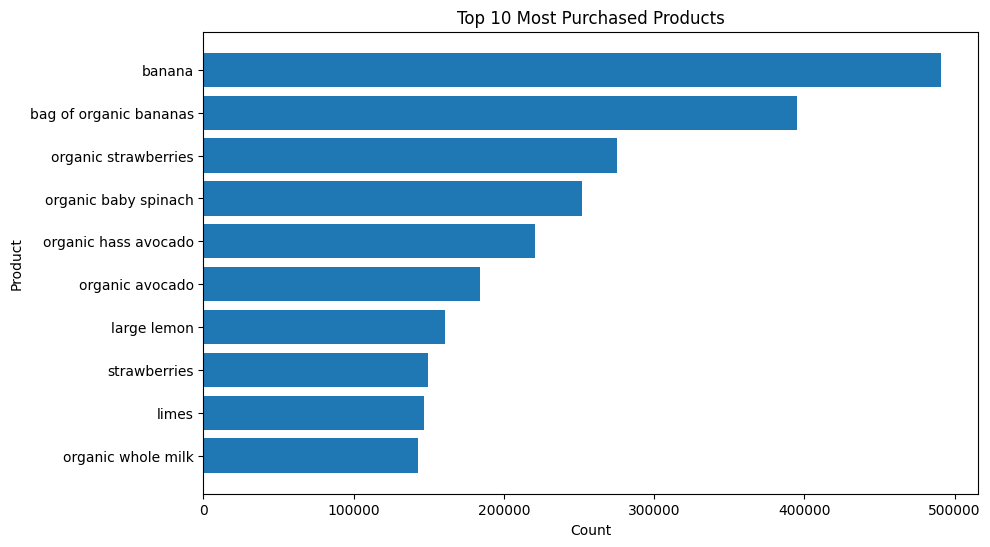

In [76]:
top_products = cleaned_df.groupBy("product_name_normalized") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

top_products_pd = top_products.toPandas()

plt.figure(figsize=(10,6))
plt.barh(top_products_pd["product_name_normalized"], top_products_pd["count"])
plt.gca().invert_yaxis()
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Count")
plt.ylabel("Product")
plt.show()

Գրաֆիկը ցույց է տալիս, որ ամենաշատ գնվող ապրանքները հիմնականում թարմ մթերքներն են, հատկապես մրգերը և բանջարեղենը։ Ամենաբարձր հաճախականությամբ գնվող ապրանքն է `banana`, որին հաջորդում են `bag of organic bananas`, `organic strawberries` և `organic baby spinach`։

Սա ցույց է տալիս, որ օգտատերերը հիմնականում նախընտրում են ամենօրյա օգտագործման թարմ և առողջ սննդամթերք։

**Ազդեցություն (Interpretation)**  
Այս pattern-ը վկայում է, որ գնումները կենտրոնացած են հաճախ օգտագործվող ապրանքների վրա, որոնք ունեն բարձր կրկնվող պահանջարկ։ Սա կարևոր է supply chain-ի և inventory management-ի համար։

**Եզրակացություն**  
Օգտատերերի գնման վարքագիծը ցույց է տալիս հստակ ուղղվածություն դեպի թարմ և հաճախ օգտագործվող ապրանքներ, ինչը կարող է օգտագործվել demand forecasting և recommendation համակարգերում։

## Reorder Rate (Visualization 2)

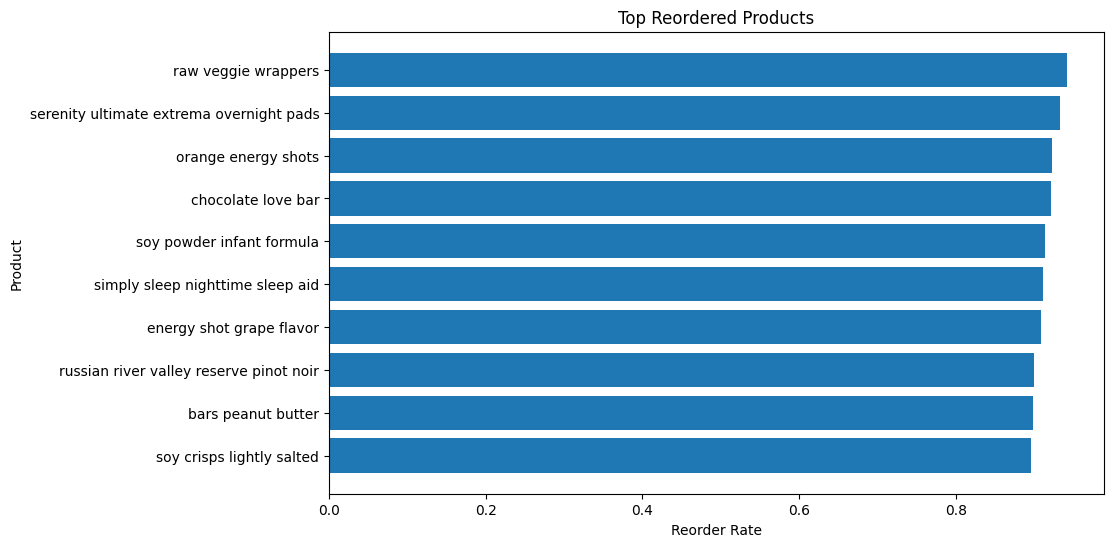

In [77]:
reorder_rate = cleaned_df.groupBy("product_name_normalized") \
    .agg((sum("reordered") / count("*")).alias("reorder_rate")) \
    .orderBy(col("reorder_rate").desc()) \
    .limit(10)

reorder_pd = reorder_rate.toPandas()

plt.figure(figsize=(10,6))
plt.barh(reorder_pd["product_name_normalized"], reorder_pd["reorder_rate"])
plt.gca().invert_yaxis()
plt.title("Top Reordered Products")
plt.xlabel("Reorder Rate")
plt.ylabel("Product")
plt.show()

Գրաֆիկը ցույց է տալիս այն ապրանքները, որոնք ունեն ամենաբարձր վերապատվիրման մակարդակը (reorder rate)։ Տեսնում ենք, որ որոշ ապրանքներ ունեն գրեթե 90%+ վերապատվիրման հավանականություն, օրինակ՝  
- `raw veggie wrappers`  
- `serenity ultimate overnight pads`  
- `orange energy shots`  

Սա նշանակում է, որ այս ապրանքները հաճախ գնում են կրկին նույն օգտատերերի կողմից։

**Ազդեցություն**  
Բարձր reorder rate ունեցող ապրանքները սովորաբար հանդիսանում են կամ  
- ամենօրյա օգտագործման ապրանքներ (consumables),  
կամ  
- ապրանքներ, որոնց նկատմամբ ձևավորվել է strong user loyalty  

Սա կարևոր է recommendation համակարգերի համար, քանի որ նման ապրանքները կարելի է հեշտությամբ առաջարկել օգտատերերին։

**Եզրակացություն**  
Բարձր վերապատվիրման մակարդակ ունեցող ապրանքները ցույց են տալիս կայուն և կրկնվող պահանջարկ, ինչը կարևոր է ինչպես մարքեթինգային, այնպես էլ supply chain ռազմավարությունների համար։

## User Activity Distribution (Visualization 3)

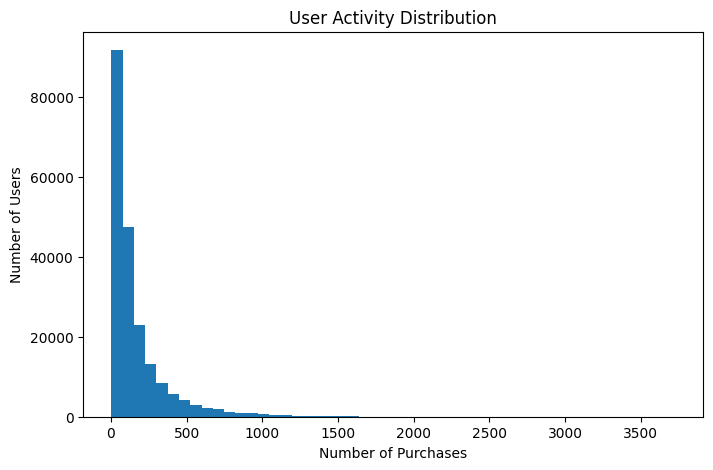

In [78]:
user_activity = cleaned_df.groupBy("user_id") \
    .count() \
    .withColumnRenamed("count", "total_purchases")

user_activity_pd = user_activity.toPandas()

plt.figure(figsize=(8,5))
plt.hist(user_activity_pd["total_purchases"], bins=50)
plt.title("User Activity Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Users")
plt.show()

Գրաֆիկը ցույց է տալիս, որ օգտատերերի ակտիվությունը ունի խիստ անհամաչափ բաշխում (highly skewed distribution)։ Օգտատերերի մեծ մասը ունի համեմատաբար քիչ գնումներ, մինչդեռ փոքր քանակությամբ օգտատերեր ունեն շատ բարձր ակտիվություն (մինչև հազարավոր գնումներ)։

**Ազդեցություն**  
Սա ցույց է տալիս, որ համակարգում առկա է «heavy users» և «light users» բաժանում։ Փոքր խմբի օգտատերեր ստեղծում են գնումների մեծ մասը, ինչը բնորոշ է իրական աշխարհում առևտրային համակարգերին։

**Եզրակացություն**  
Օգտատերերի վարքագիծը կենտրոնացված է փոքր ակտիվ խմբի վրա, ինչը կարևոր է marketing targeting-ի, loyalty ծրագրերի և personalization ռազմավարությունների համար։

## Orders by Hour (Visualization 4)

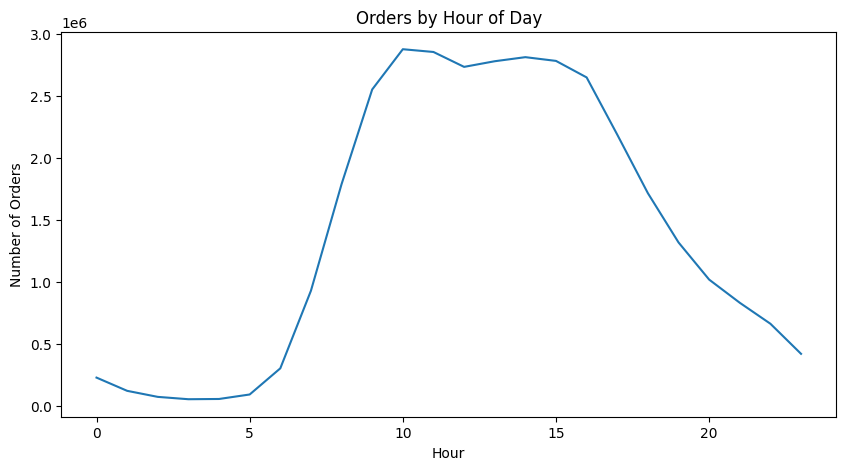

In [79]:
orders_by_hour = cleaned_df.groupBy("order_hour_of_day") \
    .count() \
    .orderBy("order_hour_of_day")

orders_by_hour_pd = orders_by_hour.toPandas()

plt.figure(figsize=(10,5))
plt.plot(orders_by_hour_pd["order_hour_of_day"], orders_by_hour_pd["count"])
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.show()

Գրաֆիկը ցույց է տալիս, որ պատվերների քանակը զգալիորեն աճում է առավոտյան ժամերից սկսած և հասնում է իր գագաթնակետին մոտավորապես 10:00–15:00 ժամանակահատվածում։ Դրանից հետո պատվերների քանակը աստիճանաբար նվազում է։

**Ազդեցություն**  
Այս pattern-ը ցույց է տալիս, որ օգտատերերի մեծ մասը կատարում է գնումներ օրվա ակտիվ ժամերին, երբ մարդիկ ավելի հաճախ են առցանց կամ զբաղվում են առօրյա գործերով։ Գիշերային ժամերին ակտիվությունը զգալիորեն ցածր է։

**Եզրակացություն**  
Օրվա ժամերը զգալի ազդեցություն ունեն գնման վարքագծի վրա, ինչը կարևոր է մարքեթինգային արշավների ժամանակավորման, push notifications-ի և promotion-ների պլանավորման համար։

## Reorder Rate by Hour (Visualization 5)

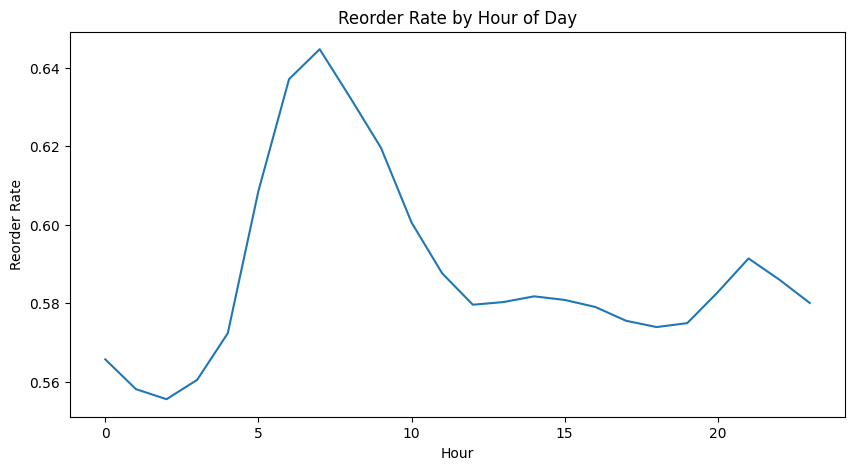

In [80]:
reorder_by_hour = cleaned_df.groupBy("order_hour_of_day") \
    .agg(avg("reordered").alias("reorder_rate")) \
    .orderBy("order_hour_of_day")

reorder_by_hour_pd = reorder_by_hour.toPandas()

plt.figure(figsize=(10,5))
plt.plot(reorder_by_hour_pd["order_hour_of_day"], reorder_by_hour_pd["reorder_rate"])
plt.title("Reorder Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Reorder Rate")
plt.show()

Գրաֆիկը ցույց է տալիս, որ վերապատվիրման մակարդակը (reorder rate) ունի հստակ ժամանակային pattern։ Այն աճում է առավոտյան ժամերին և հասնում է գագաթնակետին մոտավորապես 6:00–8:00 ժամանակահատվածում, ապա աստիճանաբար նվազում է օրվա ընթացքում։

**Ազդեցություն**  
Սա նշանակում է, որ օգտատերերը առավոտյան ժամերին ավելի հաճախ են գնում արդեն նախկինում գնված ապրանքներ, այսինքն՝ այդ ժամերին գնումները ավելի “պահպանողական” են։ Օրվա ավելի ուշ ժամերին օգտատերերը կարող են ավելի շատ փորձել նոր ապրանքներ։

**Եզրակացություն**  
Վերապատվիրման վարքագիծը կախված է օրվա ժամերից, ինչը կարևոր է personalization-ի և recommendation համակարգերի համար։ Օրինակ՝ առավոտյան կարելի է առաջարկել նախկինում գնված ապրանքներ, իսկ երեկոյան՝ նոր առաջարկներ։

## Limitations and Potential Bias

Չնայած իրականացվել է տվյալների մաքրում և օպտիմալացում, որոշ տվյալների որակի խնդիրներ և սահմանափակումներ կարող են ազդել ստացված արդյունքների վրա։

**1. Missing values (orders)**  
`days_since_prior_order` դաշտում բացակա արժեքները վերաբերում են առաջին պատվերներին։ Եթե դրանք սխալ կերպով մեկնաբանվեն կամ փոխարինվեն, կարող են խեղաթյուրել օգտատերերի վարքագծի վերլուծությունը։

**2. Missing category information (products)**  
Որոշ ապրանքներ չունեին վավեր `aisle_id` և `department_id` և հեռացվել են։ Չնայած դրանց քանակը շատ փոքր է, հնարավոր է որոշ կատեգորիաներ թերի ներկայացված լինեն։

**3. Duplicate handling**  
Տվյալների միավորման ընթացքում առաջացած կրկնությունները հեռացվել են բիզնես տրամաբանության հիման վրա։ Սակայն հնարավոր է որոշ եզակի դեպքերում իրական կրկնվող վարքագիծը մասնակիորեն չհաշվառվի։

**4. Lack of price information**  
Տվյալների հավաքածուն չի պարունակում գների մասին տեղեկատվություն, ինչի պատճառով ընդհանուր ծախսը (total spend) գնահատվել է գնումների քանակով։ Սա կարող է չարտացոլել իրական ֆինանսական վարքագիծը։

**5. Sampling and dataset structure**  
Տվյալները բաժանված են `prior` և `train` հատվածների, ինչը կարող է ազդել որոշ վերլուծությունների ամբողջականության վրա, եթե չհաշվի առնվի dataset-ի կառուցվածքը։

**Եզրակացություն**  
Վերոնշյալ սահմանափակումները պետք է հաշվի առնել արդյունքների մեկնաբանման ժամանակ, քանի որ դրանք կարող են որոշ չափով ազդել ստացված insight-ների ճշգրտության վրա։

# 5․ What breaks if data grows 100x?

Եթե տվյալների ծավալը աճի 100 անգամ, ներկայիս pipeline-ում կարող են առաջանալ մի շարք խնդիրներ։

**1. Shuffle overhead (Exchange operations)**  
Մեծ տվյալների դեպքում `Exchange` գործողությունները կդառնան հիմնական bottleneck-ը, քանի որ տվյալների վերաբաշխումը կպահանջի մեծ ցանցային և հաշվարկային ռեսուրսներ։

**2. SortMergeJoin performance**  
Մեծ աղյուսակների join-երը (`order_products` և `orders`) օգտագործում են `SortMergeJoin`, որը պահանջում է sorting և մեծ քանակությամբ հիշողություն։ Տվյալների աճի դեպքում սա կարող է դառնալ շատ դանդաղ կամ նույնիսկ չկատարվել բավարար ռեսուրսների բացակայության պատճառով։

**3. Memory pressure and spill to disk**  
Aggregation-ները և join-երը կարող են գերազանցել available memory-ը, ինչի արդյունքում Spark-ը կսկսի տվյալները գրել disk (spill), ինչը զգալիորեն կդանդաղեցնի pipeline-ը։

**4. toPandas() bottleneck**  
Visualization-ի համար օգտագործված `.toPandas()` մեթոդը չի կարող աշխատել մեծ տվյալների դեպքում, քանի որ ամբողջ dataset-ը բերվում է driver memory, ինչը կարող է հանգեցնել out-of-memory error-ի։

**5. Skewed data distribution**  
Քանի որ օգտատերերի ակտիվությունը skewed է (heavy users), որոշ partition-ներ կարող են դառնալ շատ ծանր, ինչը կհանգեցնի task imbalance-ի և performance-ի անկմանը։

---

**Potential Solutions**

- Օգտագործել ավելի մեծ cluster և ավելացնել executor memory
- Կիրառել ավելի խելացի partitioning և skew handling (salting)
- Խուսափել `.toPandas()`-ից և օգտագործել distributed visualization մեթոդներ
- Cache intermediate results (`.cache()` / `.persist()`)
- Օգտագործել ավելի արդյունավետ join strategies (broadcast, bucketing)

---

**Եզրակացություն**  
Տվյալների ծավալի մեծացման դեպքում հիմնական խնդիրները կապված կլինեն shuffle-ի, memory-ի և join-երի հետ։ Դրանց լուծումը պահանջում է ինչպես ռեսուրսների ավելացում, այնպես էլ pipeline-ի ավելի խորը օպտիմալացում։